# Gradient Analysis on MNIST

This notebook investigates how gradients change during training, comparing early vs. late layers and the effect of initialization.

## Goals
1. Track mean gradient norms per layer over epochs.
2. Compare early vs. late layers.
3. Compare Default Initialization vs. Manual Initialization (Normal(0, 1)).
4. Verify reproducibility with multiple seeds.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Configuration
BATCH_SIZE = 64
LR = 0.01
EPOCHS = 10
SEEDS = [42, 1337, 2023]
DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: mps


## Data Loading

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

## Model Definition

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        # Deep enough to see differences between layers
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),  # input layer 0
            nn.ReLU(),
            nn.Linear(256, 128),    # layer 1
            nn.ReLU(),
            nn.Linear(128, 64),     # layer 2
            nn.ReLU(),
            nn.Linear(64, 64),      # layer 3
            nn.ReLU(),
            nn.Linear(64, 10)       # output layer 4
        )

    def forward(self, x):
        return self.layers(x)

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.grad is not None and "weight" in name:
            # Calculate L2 norm of gradients
            norms[name] = param.grad.norm().item()
    return norms

## Training Helper

In [7]:
def train_and_track(model, loader, optimizer, epochs):
    model.train()
    criterion = nn.CrossEntropyLoss()
    
    # Store mean gradient norms per epoch for each layer
    epoch_grad_norms = {name: [] for name, _ in model.named_parameters() if "weight" in name}
    
    for epoch in range(epochs):
        batch_grad_norms = {name: [] for name in epoch_grad_norms}
        
        for batch_idx, (data, target) in enumerate(loader):
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            
            # Record gradients
            norms = get_gradient_norms(model)
            for name, val in norms.items():
                batch_grad_norms[name].append(val)
            
            optimizer.step()
        
        # Average over batches for this epoch
        print(f"Epoch {epoch+1}/{epochs} completed.")
        for name in epoch_grad_norms:
            if batch_grad_norms[name]:
                epoch_grad_norms[name].append(np.mean(batch_grad_norms[name]))
            else:
                epoch_grad_norms[name].append(0.0)
                
    return epoch_grad_norms

## Experiment 1: Default Initialization

In [8]:
results_default = {}

for seed in SEEDS:
    print(f"\nRunning Default Init with Seed {seed}...")
    torch.manual_seed(seed)
    model = MLP().to(DEVICE)
    optimizer = optim.SGD(model.parameters(), lr=LR)
    
    grads = train_and_track(model, train_loader, optimizer, EPOCHS)
    results_default[seed] = grads


Running Default Init with Seed 42...
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.
Epoch 7/10 completed.
Epoch 8/10 completed.
Epoch 9/10 completed.
Epoch 10/10 completed.

Running Default Init with Seed 1337...
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.
Epoch 7/10 completed.
Epoch 8/10 completed.
Epoch 9/10 completed.
Epoch 10/10 completed.

Running Default Init with Seed 2023...
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.
Epoch 7/10 completed.
Epoch 8/10 completed.
Epoch 9/10 completed.
Epoch 10/10 completed.


## Experiment 2: Manual Initialization (Normal(0, std))

In [50]:
std = 0.1

def init_weights_normal(m):
    if isinstance(m, nn.Linear):    # onyl applied if layer is nn.Linear, not ReLU or something else
        nn.init.normal_(m.weight, mean=0.0, std=std)
        nn.init.zeros_(m.bias)

results_manual = {}

for seed in SEEDS:
    print(f"\nRunning Manual Init (Normal(0,{std})) with Seed {seed}...")
    torch.manual_seed(seed)
    model = MLP().to(DEVICE)
    model.apply(init_weights_normal)
    optimizer = optim.SGD(model.parameters(), lr=LR)
    
    grads = train_and_track(model, train_loader, optimizer, EPOCHS)
    results_manual[seed] = grads


Running Manual Init (Normal(0,0.1)) with Seed 42...
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.
Epoch 7/10 completed.
Epoch 8/10 completed.
Epoch 9/10 completed.
Epoch 10/10 completed.

Running Manual Init (Normal(0,0.1)) with Seed 1337...
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.
Epoch 7/10 completed.
Epoch 8/10 completed.
Epoch 9/10 completed.
Epoch 10/10 completed.

Running Manual Init (Normal(0,0.1)) with Seed 2023...
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.
Epoch 7/10 completed.
Epoch 8/10 completed.
Epoch 9/10 completed.
Epoch 10/10 completed.


## Visualization

Plotting Default Initialization Results...


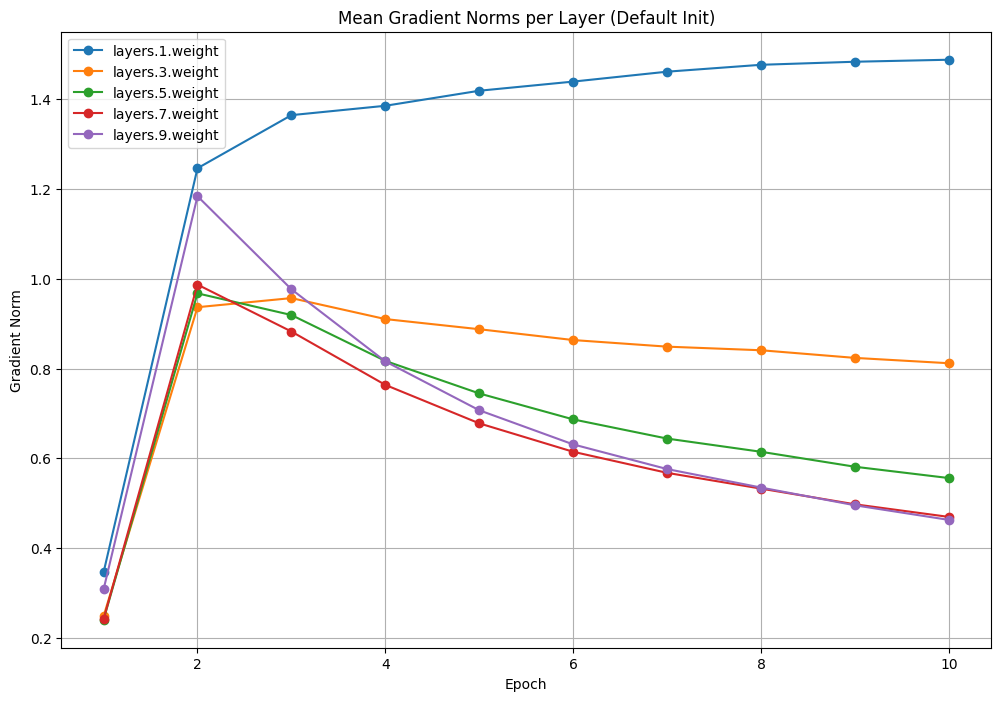

Plotting Manual Initialization Results for std 0.1...


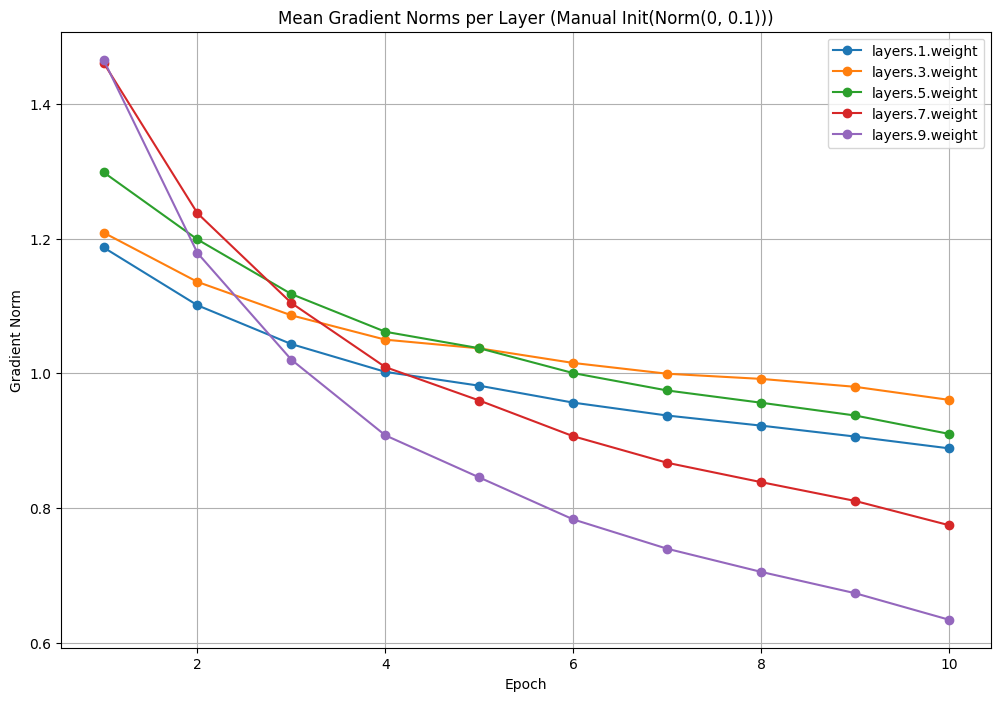

In [51]:
def plot_results(results, title):
    plt.figure(figsize=(12, 8))
    
    # Average over seeds
    avg_grads = {}
    first_seed = list(results.keys())[0]
    layer_names = results[first_seed].keys()
    
    for name in layer_names:
        all_seeds_layer_data = []
        for seed in results:
            all_seeds_layer_data.append(results[seed][name])
        avg_grads[name] = np.mean(all_seeds_layer_data, axis=0)
        
    epochs = range(1, EPOCHS + 1)
    
    for name, grads in avg_grads.items():
        plt.plot(epochs, grads, label=name, marker='o')
        #plt.plot(grads, epochs, label=name, marker='o')
        
    plt.title(f"Mean Gradient Norms per Layer ({title})")
    plt.xlabel("Epoch")
    plt.ylabel("Gradient Norm")
    plt.legend()
    plt.grid(True)
    #plt.yscale('log') # Log scale to see differences better
    plt.show()

print("Plotting Default Initialization Results...")
plot_results(results_default, "Default Init")

print(f"Plotting Manual Initialization Results for std {std}...")
plot_results(results_manual, f"Manual Init(Norm(0, {std}))")